# 1. Import thư viện

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.datasets import load_iris

sns.set(style="whitegrid")

# 2. DATA


In [33]:
data = load_iris()
X = data.data
feature_names = data.feature_names

df = pd.DataFrame(X, columns=feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


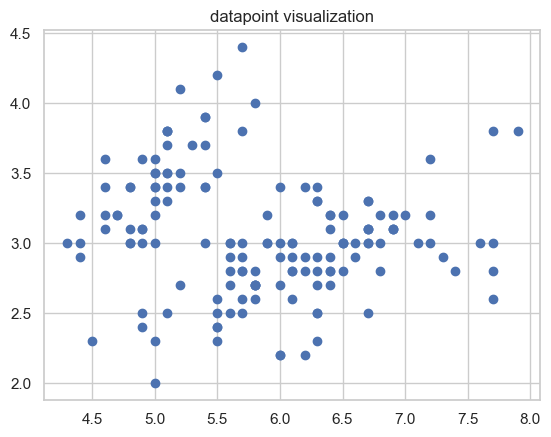

In [6]:
plt.scatter(X[:, 0], X[:, 1])
plt.title("datapoint visualization")
plt.show()

# Khởi tạo mô hình & tìm số cụm tối ưu

In [ ]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, init='k-means++', random_state=42)
    model.fit(X)
    wcss.append(model.inertia_)
    print(f"K={k} | WCSS={model.inertia_:.2f}")

# xác định điểm gãy
print("-" * 20)
for i in range(1, len(wcss)):
    diff = wcss[i-1] - wcss[i]
    print(f"K={i}->{i+1} giảm: {diff:.2f}")

K=1 | WCSS=681.37
K=2 | WCSS=152.35
K=3 | WCSS=78.86
K=4 | WCSS=57.35
K=5 | WCSS=46.47
K=6 | WCSS=39.07
K=7 | WCSS=34.31
K=8 | WCSS=30.48
K=9 | WCSS=29.91
K=10 | WCSS=28.55
--------------------
K=1->2 giảm: 529.02
K=2->3 giảm: 73.49
K=3->4 giảm: 21.50
K=4->5 giảm: 10.88
K=5->6 giảm: 7.41
K=6->7 giảm: 4.76
K=7->8 giảm: 3.83
K=8->9 giảm: 0.57
K=9->10 giảm: 1.36


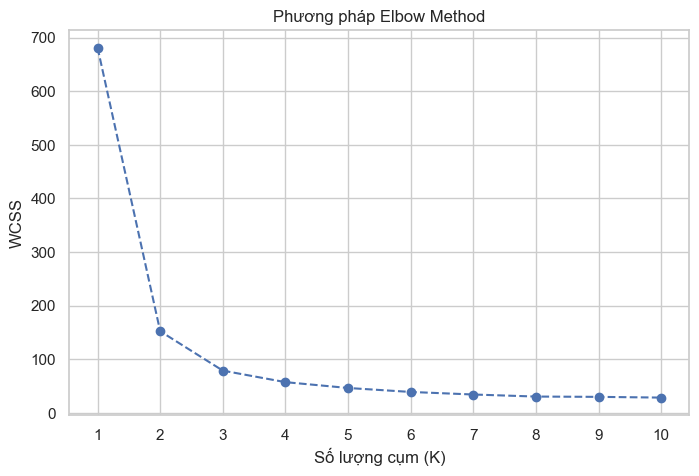

In [49]:
import matplotlib.pyplot as plt

wcss_values = [681.37, 152.35, 78.86, 57.35, 46.47, 39.07, 34.31, 30.48, 29.91, 28.55]
k_range = range(1, 11)

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss_values, marker='o', linestyle='--', color='b')

plt.title('Phương pháp Elbow Method')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('WCSS')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [50]:
model = KMeans(n_clusters=3, random_state=42)

y_predict = model.fit_predict(X)

score = silhouette_score(X, y_predict)

print(f"Chỉ số Silhouette Score của cụm 3: {score:.4f}")

Chỉ số Silhouette Score của cụm 3: 0.5512


# Chọn số phân cụm là 3


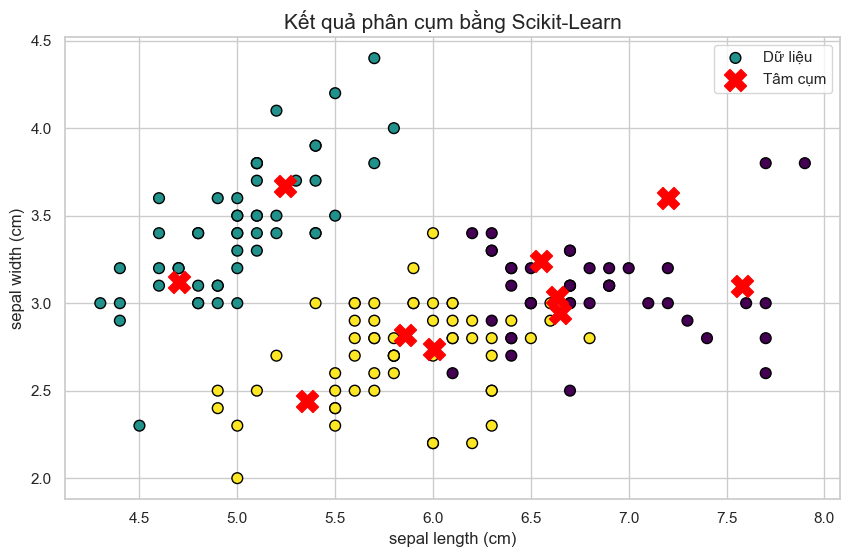

In [51]:
plt.figure(figsize=(10, 6))

plt.scatter(X[:, 0], X[:, 1], c=y_predict, cmap='viridis', s=60, edgecolors='black', label='Dữ liệu')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=250, c='red', marker='X', label='Tâm cụm')

plt.title("Kết quả phân cụm bằng Scikit-Learn", fontsize=15)
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend()
plt.show()

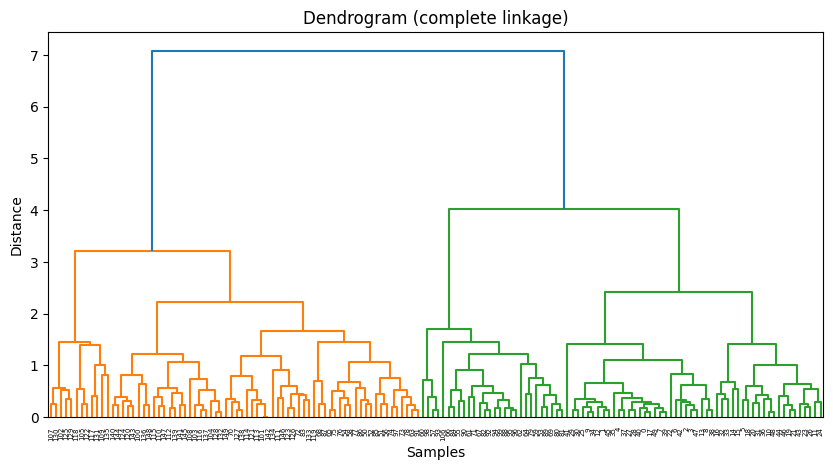

In [ ]:
def plot_dendrogram(X, method="complete"):
    """
    Vẽ dendrogram cho hierarchical clustering
    """
    Z = linkage(X, method=method)

    plt.figure(figsize=(10, 5))
    dendrogram(Z)
    plt.title(f"Dendrogram ({method} linkage)")
    plt.xlabel("Samples")
    plt.ylabel("Distance")
    plt.show()

plot_dendrogram(X)

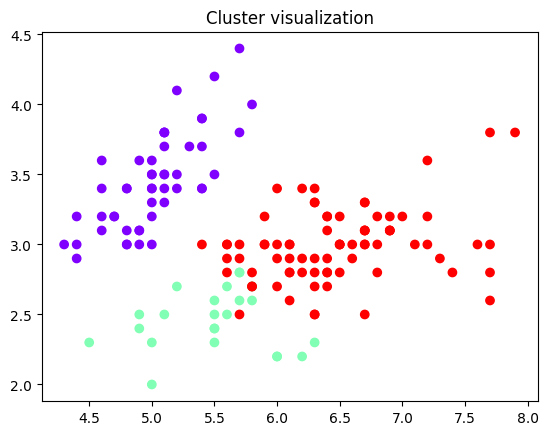

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow')
plt.title("Cluster visualization")
plt.show()

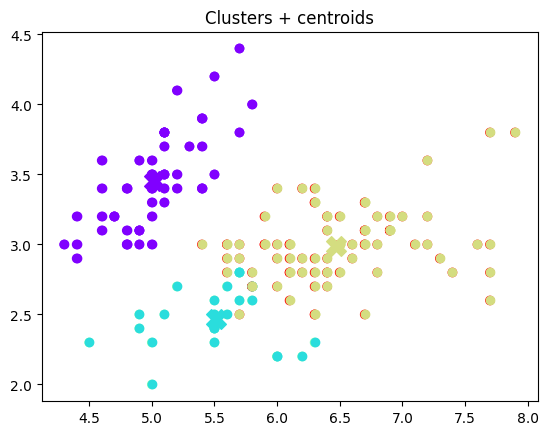

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow')
for c in np.unique(labels):
    points = X[labels == c]
    centroid = points.mean(axis=0)
    
    color = plt.cm.rainbow(c / len(np.unique(labels)))
    
    plt.scatter(points[:, 0], points[:, 1], color=color)
    plt.scatter(centroid[0], centroid[1], s=200, marker='X', color=color)

plt.title("Clusters + centroids")
plt.show()

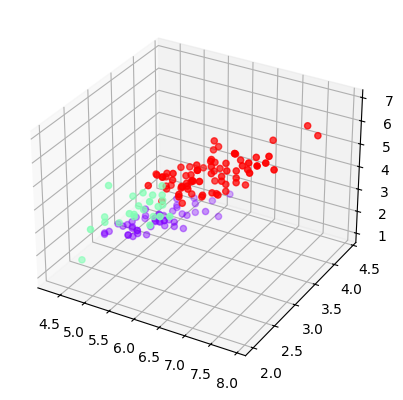

In [ ]:

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels, cmap='rainbow')

plt.show()


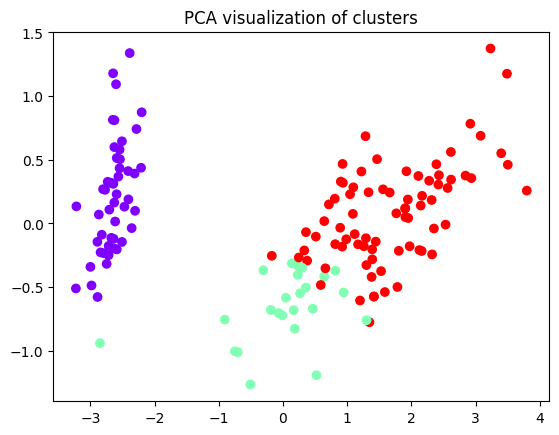

In [ ]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='rainbow')
plt.title("PCA visualization of clusters")
plt.show()